Making a slippy map based on LODES Data  ! 

In [1]:
!python -m venv C:\GreenGIS\Sankey
!C:\GreenGIS\Sankey\activate.bat
!PS C:\GreenGIS\SankeyScripts\Activate.ps1

'C:\GreenGIS\Sankey\activate.bat' is not recognized as an internal or external command,
operable program or batch file.


      PID    PPID    PGID     WINPID   TTY         UID    STIME COMMAND
    20368       1   20368      20368  ?         197610 09:21:25 /usr/bin/ps


In [2]:
#necessary libraries
!python -m pip install virtualenv
!python -m pip install pygris
!python -m pip install folium matplotlib mapclassify
!python -m pip install xlwt
!python -m pip install git+https://github.com/walkerke/pygris.git


[notice] A new release of pip is available: 24.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


^C


In [2]:
#C:\GreenGIS\Sankey
# Your Python script code goes here
#print("This script is running within the virtual environment")

This script is running within the virtual environment


In [ ]:
from pygris import tracts
from pygris.data import get_lodes
from pyproj import CRS
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import mapclassify as mc
from shapely.geometry import Point
from shapely.geometry import MultiPoint
import folium
import geojson
import requests


In [4]:
#step 1 get lodes
va_lodes_od = get_lodes(
    state = "VA",
    year = 2021,
    lodes_type = "od")

va_lodes_od.head()

,index,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03
0,0,510010901011006,510010902023010,1,0,1,0,1,0,0,0,0,1
1,1,510010901011011,510010901011027,1,0,1,0,0,1,0,1,0,0
2,2,510010901011011,510010901011033,1,0,0,1,0,1,0,0,1,0
3,3,510010901011011,510010901011041,1,1,0,0,1,0,0,0,1,0
4,4,510010901011011,510010901021002,1,0,0,1,0,1,0,0,1,0


In [4]:
#step 2 assign a census tract to be a work destination
#and assign a count from each home tract that goes to that destination
#vcu main campus tract 	51760040300
#another to test would be the Cenus tract for MCV/Biotech Park 51760030200
vcu = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('w_tract == "51760040300"')
    .groupby('h_tract', as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'vcu'}, axis = 1)
)

vcu.head()

,h_tract,vcu
0,51001090101,1
1,51001090600,2
2,51001090700,1
3,51003010201,2
4,51003010202,1


In [5]:
#make a rate for that commute desintation
vcu_commuters = (
    va_lodes_od
    .assign(h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .groupby('h_tract', as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'total_workers'}, axis = 1)
    .merge(vcu, on = 'h_tract')
    .assign(vcu_per_1000 = lambda x: 1000 * (x['vcu'] / x['total_workers']))
)

vcu_commuters.head()

,h_tract,total_workers,vcu,vcu_per_1000
0,51001090101,731,1,1.367989
1,51001090600,1753,2,1.140901
2,51001090700,1933,1,0.517331
3,51003010201,2251,2,0.888494
4,51003010202,1344,1,0.744048


In [6]:
#saving to excel - just in case - 
vcu_commuters.to_excel(r'C:\GreenGIS\Sankey\vcu.xls', index=False)

C:\Users\egreenwell\AppData\Local\Temp\ipykernel_11900\2964307291.py:2: FutureWarning: As the xlwt package is no longer maintained, the xlwt engine will be removed in a future version of pandas. This is the only engine in pandas that supports writing in the xls format. Install openpyxl and write to an xlsx file instead. You can set the option io.excel.xls.writer to 'xlwt' to silence this warning. While this option is deprecated and will also raise a warning, it can be globally set and the warning suppressed.
  vcu_commuters.to_excel(r'C:\GreenGIS\Sankey\vcu.xls', index=False)


Using FIPS code '51' for input 'VA'
Using FIPS code '036' for input 'Charles City'
Using FIPS code '041' for input 'Chesterfield'
Using FIPS code '075' for input 'Goochland'
Using FIPS code '087' for input 'Henrico'
Using FIPS code '085' for input 'Hanover'
Using FIPS code '127' for input 'New Kent'
Using FIPS code '145' for input 'Powhatan'
Using FIPS code '760' for input 'Richmond City'


,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
2,51,087,200404,1400000US51087200404,51087200404,2004.04,Census Tract 2004.04,VA,Henrico County,Virginia,CT,2144770,43191,"POLYGON ((-77.51815 37.60846, -77.51339 37.610..."
5,51,760,020200,1400000US51760020200,51760020200,202,Census Tract 202,VA,Richmond city,Virginia,CT,1001402,0,"POLYGON ((-77.41410 37.54950, -77.41213 37.552..."
6,51,760,060900,1400000US51760060900,51760060900,609,Census Tract 609,VA,Richmond city,Virginia,CT,2792220,0,"POLYGON ((-77.45024 37.46060, -77.44869 37.469..."
9,51,760,021200,1400000US51760021200,51760021200,212,Census Tract 212,VA,Richmond city,Virginia,CT,910277,0,"POLYGON ((-77.40888 37.51511, -77.40631 37.514..."
13,51,087,200134,1400000US51087200134,51087200134,2001.34,Census Tract 2001.34,VA,Henrico County,Virginia,CT,4590484,1335,"POLYGON ((-77.59825 37.59246, -77.59693 37.593..."


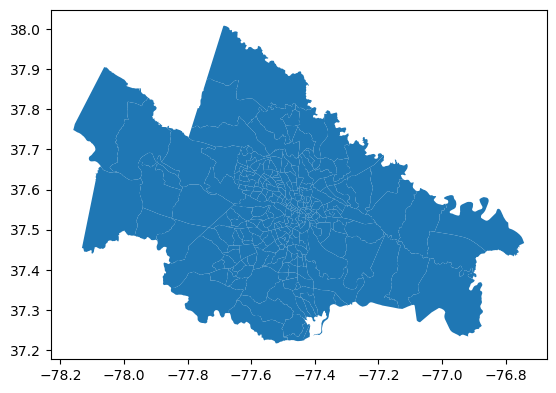

In [7]:
#find our region tracts - plot to ensure it looks right 
planrva_tracts = tracts(state = "VA", cb = True,
                    county = ["Charles City", "Chesterfield", "Goochland", "Henrico",
                              "Hanover", "New Kent", "Powhatan", "Richmond City"], 
                    year = 2021)
             
planrva_tracts.plot()
planrva_tracts.head()

c:\Users\egreenwell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


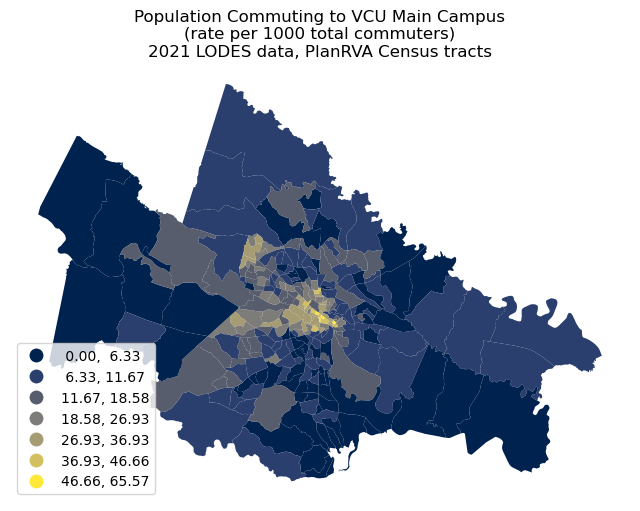

In [8]:
#join and make static figure

vcu_region = planrva_tracts.merge(vcu_commuters, left_on = "GEOID", right_on = "h_tract",
                             how = "left")

vcu_region.fillna(0, inplace = True)

vcu_region.plot(column = 'vcu_per_1000', legend = True, 
               cmap = "cividis", figsize = (8, 8), 
               k = 7, scheme = "naturalbreaks",
               legend_kwds = {"loc": "lower left"})

plt.title("Population Commuting to VCU Main Campus\n(rate per 1000 total commuters)\n2021 LODES data, PlanRVA Census tracts", fontsize = 12)

ax = plt.gca()

ax.set_axis_off()

plt.savefig(r'C:\GreenGIS\Sankey\vcu2.png')

In [9]:
#join and make slippy feature

from pygris.geocode import geocode


vcu_region_sub = vcu_region.filter(['GEOID', 'total_workers',
                                  'vcu', 'vcu_per_1000', 'geometry'])

monroe_park = geocode("620 W Main St, Richmond, VA 23220",
                         as_gdf = True)

m = vcu_region_sub.explore(column = "vcu_per_1000", cmap = "cividis",
                          k = 7, scheme = "naturalbreaks", popup = True, 
                          tooltip = False,                   
                          tiles = "CartoDB positron", 
                          style_kwds = {"weight": 0.5},
                          legend_kwds = {"caption": "Population Commuting to VCU Main Campus",
                                          "colorbar": False},
                          popup_kwds = {"aliases": ['Census tract', 'Total workers',
                                                    'VCU-area commuters', 'Rate per 1000']})

monroe_park.explore(m = m, marker_type = "marker", tooltip = False)  

c:\Users\egreenwell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Making O/D Data with points for the region! 

In [3]:
#first testing people who commute TO tracts in Charles city
charles_city = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("510366")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)

charles_city.head()

C:\Users\egreenwell\AppData\Local\Temp\ipykernel_28260\1168790302.py:8: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'S000': sum})


,w_tract,h_tract,workers
0,51001090500,51036600100,5
1,51001090500,51036600200,2
2,51001090500,51036600300,2
3,51003010401,51036600100,1
4,51003010502,51036600100,1


In [ ]:
#first testing people who commute TO tracts in Charles city
charles_city = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('w_tract.str.startswith("510366")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)

charles_city.head()

In [39]:
#checking counts of those living outside region and those working outside our region 
df = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('w_tract.str.startswith("517600")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)

C:\Users\egreenwell\AppData\Local\Temp\ipykernel_28260\59722729.py:8: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'S000': sum})


In [40]:
Total = df['workers'].sum()
print(Total)

148189


In [5]:
charles_city.to_excel(r'C:\GreenGIS\Slippy-LODES\charles_city.xlsx', index=False)

In [ ]:
chesterfield = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("510411")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)

chesterfield.to_excel(r'C:\GreenGIS\Sankey\chesterfield.xls', index=False)

goochland = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("510754")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)
goochland.to_excel(r'C:\GreenGIS\Sankey\goochland.xls', index=False)
hanover = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("510853")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)
hanover.to_excel(r'C:\GreenGIS\Sankey\hanover.xls', index=False)
henrico = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("510872")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)
henrico.to_excel(r'C:\GreenGIS\Sankey\henrico.xls', index=False)
newkent = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("511277")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)
newkent.to_excel(r'C:\GreenGIS\Sankey\newkent.xls', index=False)
powhatan = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("511455")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)
powhatan.to_excel(r'C:\GreenGIS\Sankey\powhatan.xls', index=False)
richmond = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .query('h_tract.str.startswith("517600")')
    .groupby(['w_tract', 'h_tract'], as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)
richmond.to_excel(r'C:\GreenGIS\Sankey\richmond.xls', index=False)

In [ ]:
# copy GeoDataFrame
points = planrva_tracts.copy()
# change geometry 
points['geometry'] = points['geometry'].centroid
points.head()
points.to_excel(r'C:\GreenGIS\Sankey\points.xls', index=False)

In [ ]:
#test sankey with Charles City
#Change POINTS to X, Y columns 

#charles_city = pd.read_excel(r'C:\GreenGIS\Sankey\charles_city.xls')

#POINT (-77.19172130016469 37.384721328220856)
df = pd.read_csv(r'C:\GreenGIS\Sankey\points.csv')

# Convert the 'geometry' column to a string format
df['geometry'] = df['geometry'].astype(str)

# Split the 'geometry' column into separate X and Y columns
df[['point_type', 'coordinates']] = df['geometry'].str.split(' ', 1, expand=True)
df[['X', 'Y']] = df['coordinates'].str.extract(r'\((-?\d+\.\d+) (-?\d+\.\d+)\)')

# Convert X and Y columns to numeric type
df['X'] = pd.to_numeric(df['X'])
df['Y'] = pd.to_numeric(df['Y'])

# Drop unnecessary columns
df.drop(columns=['geometry', 'point_type', 'coordinates'], inplace=True)

# Create a GeoDataFrame from the DataFrame with Point geometries
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['X'], df['Y']))

# Display the GeoDataFrame
print(gdf)

# Save the modified GeoDataFrame back to an Excel file
gdf.to_excel('points.xlsx', index=False)

In [ ]:
#Charles City X/Y points 
# Create MultiPoint geometry for work locations
work_multipoint = MultiPoint(charles_city.apply(lambda row: (row['WorkX'], row['WorkY']), axis=1))

# Create MultiPoint geometry for home locations
home_multipoint = MultiPoint(charles_city.apply(lambda row: (row['HomeX'], row['HomeY']), axis=1))

# Create a column containing MultiPoint geometries for work and home locations
charles_city['work_home_multipoint'] = charles_city.apply(lambda row: MultiPoint([row['WorkX'], row['WorkY'], row['HomeX'], row['HomeY']]), axis=1)

In [ ]:
#reread points here as excel - begin joining to other counties
points = pd.read_excel(r'C:\GreenGIS\Sankey\outputs\points.xlsx')

chesterfield = pd.read_excel(r'C:\GreenGIS\Sankey\outputs\chesterfield.xls')
#goochland = pd.read_excel(r'C:\GreenGIS\Sankey\goochland.xls')
#hanover = pd.read_excel(r'C:\GreenGIS\Sankey\hanover.xls')
#henrico = pd.read_excel(r'C:\GreenGIS\Sankey\henrico.xls')
#newkent = pd.read_excel(r'C:\GreenGIS\Sankey\newkent.xls')
#powhatan = pd.read_excel(r'C:\GreenGIS\Sankey\powhatan.xls')
#richmond = pd.read_excel(r'C:\GreenGIS\Sankey\richmond.xls')


# Iterate over each row in points
for index, row in points.iterrows():
    # Find the corresponding row in chesterfield where 'w_tract' matches 'GEOID'
    matching_rows = chesterfield.loc[chesterfield['h_tract'] == row['GEOID']]
    if not matching_rows.empty:
         # Iterate over each matching row and update the values individually
        for match_index, match_row in matching_rows.iterrows():
        # Update 'WorkX' and 'WorkY' in chesterfield or "HomeX" and "HomeY"
            chesterfield.at[match_index, 'HomeX'] = row['X']
            chesterfield.at[match_index, 'HomeY'] = row['Y']
            # Update 'w_county' or "h_county" in chesterfield_df based on 'NAMELSADCO'
            chesterfield.at[match_index, 'h_county'] = row['NAMELSADCO']

# Save the modified DataFrame to a new Excel file  ?- to check
#chesterfield.to_excel('chesterfield.xlsx', index=False)

chesterfield.head()

In [6]:
# Iterate over each row in points
for index, row in points.iterrows():
    # Find the corresponding row in chesterfield where 'w_tract' matches 'GEOID'
    matching_rows = chesterfield.loc[chesterfield['w_tract'] == row['GEOID']]
    if not matching_rows.empty:
         # Iterate over each matching row and update the values individually
        for match_index, match_row in matching_rows.iterrows():
            # Update 'WorkX' and 'WorkY' in chesterfield
            chesterfield.at[match_index, 'WorkX'] = row['X']
            chesterfield.at[match_index, 'WorkY'] = row['Y']
            # Update 'w_county' in chesterfield_df based on 'NAMELSADCO'
            chesterfield.at[match_index, 'w_county'] = row['NAMELSADCO']

# Drop rows where 'w_county' is empty -they are commuting outside the region
chesterfield.dropna(subset=['w_county'], inplace=True)

# Save the modified DataFrame to a new Excel file
chesterfield.to_excel('chesterfield.xlsx', index=False)

<h1>Let's Explore Richmond!</h1>

In [7]:
#Let's summarize the richmond LODES data by work tract

richmond = pd.read_csv(r'C:\GreenGIS\Sankey\outputs\richmond.csv')
#groupy by work destination tract
rvasummary = richmond.groupby('w_tract')['workers'].sum().reset_index()
#save dataframe to new csv
rvasummary.to_csv(r'C:\GreenGIS\Sankey\outputs\rvasummary.csv', index=False)

c:\Users\egreenwell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


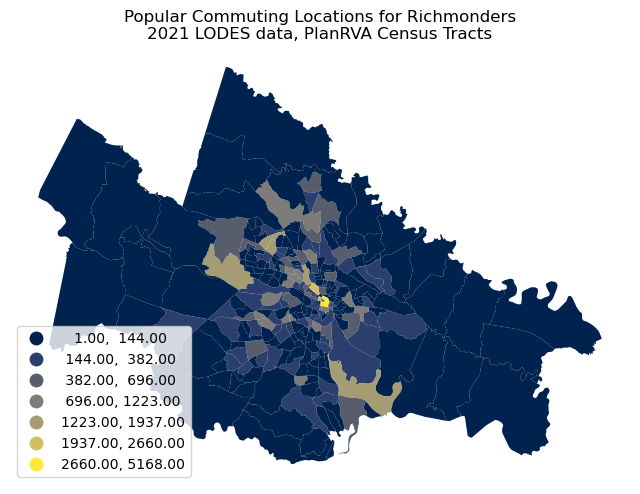

In [57]:
#We have the PlanRVA tracts from above we may use as a basemap or to focus the map.
#Yay now let's make a static map!

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import geopandas as gpd
import geoplot.crs as gcrs
import mapclassify as mc

#reread the new datafile here
rvasummary = pd.read_csv(r'C:\GreenGIS\Sankey\outputs\rvasummary.csv')
# Convert the 'w_tract' column in the 'rvasummary' DataFrame to match the data type of 'GEOID' column
rvasummary['w_tract'] = rvasummary['w_tract'].astype(str)


#join with the tracts
rva_region = planrva_tracts.join(rvasummary.set_index('w_tract'), on='GEOID', how='left')

#plot a choropleth map using Geoplot
rva_region.plot(column = 'workers', legend = True, 
               cmap = "cividis", figsize = (8, 8), 
               k=7, scheme = "naturalbreaks",
               legend_kwds = {"loc": "lower left"})

plt.title("Popular Commuting Locations for Richmonders\n2021 LODES data, PlanRVA Census Tracts", fontsize = 12)

ax = plt.gca()

ax.set_axis_off()

plt.savefig(r'C:\GreenGIS\Sankey\richmonders.png')


In [76]:
# Convert GeoDataFrame to GeoJSON
rva_geojson = rva_region.to_crs(epsg='4326').to_json()

# Create a custom colormap using linear.YlGnBu_09 scale
colormap = linear.YlGnBu_09.scale(rva_region['workers'].min(), rva_region['workers'].max())

# Create a Folium map
m = folium.Map(location=[37.5, -77.5], zoom_start=10)

# Add the GeoJSON data to the map as a Choropleth layer with popups
folium.GeoJson(
    rva_geojson,
    name='choropleth',
    style_function=lambda feature: {
            'fillColor': colormap(feature['properties']['workers']),
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.7
    },
    tooltip=folium.features.GeoJsonTooltip(fields=['workers', 'Work', 'Home'],
                                            aliases=['Total Workers', 'Work Location', 'Home Location'],
                                            labels=True,
                                            sticky=False)
    ).add_to(m)

# Add the colormap to the map
colormap.add_to(m)

# Add caption
caption = '<b>Popular Commuting Locations for Richmonders</b><br>2021 LODES data, PlanRVA Census Tracts'
m.get_root().html.add_child(folium.Element(caption))

#add color ramp
colormap.caption = "Workers Color Scale"
colormap.add_to(m)

# Display the map
m

# Snapping Commutes to the Roadway
# Top 80 Commutes - those who commute outside their county and more than 100 people commute the same census tract to census tract path

In [6]:
import geopandas as gpd
import requests
from shapely.geometry import LineString, Point


top_80 = gpd.read_file(r'C:\GreenGIS\Slippy-LODES\shps\Top_80.shp')

# Mapbox API settings
mapbox_base_url = "https://api.mapbox.com/directions/v5/mapbox"
mapbox_profile = "driving"  # Options: driving, walking, cycling
mapbox_access_token = "pk.eyJ1IjoiZWdyZWVud2VsbCIsImEiOiJjbG11bTc4MjcwMHhlMmxwaGNxNmNsYWszIn0.RZ3BCvRRCmJiXBS2Qi16kQ"  # Elizabeth's token

# Function to snap a start and end point to the road network
def snap_line_to_road(home_x, home_y, work_x, work_y):
    coords = f"{home_x},{home_y};{work_x},{work_y}"
    url = f"{mapbox_base_url}/{mapbox_profile}/{coords}"
    params = {
        "access_token": mapbox_access_token,
        "geometries": "geojson"
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        snapped_coords = response.json()["routes"][0]["geometry"]["coordinates"]
        return LineString([(x, y) for x, y in snapped_coords])
    else:
        print(f"Error snapping line: {response.text}")
        return LineString([(home_x, home_y), (work_x, work_y)])

# Snap lines based on Home and Work coordinates
snapped_lines = []
for _, row in top_80.iterrows():
    snapped_line = snap_line_to_road(row.HomeX, row.HomeY, row.WorkX, row.WorkY)
    snapped_lines.append(snapped_line)

# Create a new GeoDataFrame with snapped lines
snapped_gdf = gpd.GeoDataFrame(top_80.drop(columns='geometry'), geometry=snapped_lines, crs=top_80.crs)

# Save or visualize the results
snapped_gdf.to_file("snapped_lines.shp")  # Save to a new shapefile

c:\Users\egreenwell\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 51760030200 of field w_tract of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\egreenwell\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 51041100206 of field h_tract of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\egreenwell\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 51760030200 of field w_tract of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\egreenwell\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 51041100209 of field h_tract of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\egreenwell\anaconda3\Lib\site-packages\pyogrio\raw.py:723: 

In [8]:
snapped_gdf.explore()